
# CS667 — Project 2: Predictive Regression on Retail Sales


**What this notebook does:**
- Loads the provided Excel dataset (`retail_data_synthetic_50k.xlsx`)
- Cleans & feature‑engineers (Year, Month, DayOfWeek, IsWeekend, Season)
- Encodes categoricals & scales numerics (via `ColumnTransformer`)
- Trains **Linear Regression**, **Random Forest**, **Gradient Boosting**
- Evaluates with **R², MAE, MSE, RMSE**
- Generates **Actual vs Predicted**, **Residuals**, **Feature Importances**, **Correlation Heatmap**
- performance summary and report



## Setup & Imports

In [14]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import sklearn
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.6.1


## Load the Dataset

In [15]:

DATA_FILE = "/content/retail_data_synthetic_50k.xlsx"

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        print("Upload the dataset Excel file (retail_data_synthetic_50k.xlsx)")
        uploaded = files.upload()

        if len(uploaded) == 1:
            up_name = list(uploaded.keys())[0]
            if up_name != DATA_FILE:
                os.rename(up_name, DATA_FILE)
        elif DATA_FILE not in uploaded:
            raise FileNotFoundError(f"{DATA_FILE} not uploaded. Uploaded: {list(uploaded.keys())}")
    except Exception as e:
        raise FileNotFoundError(f"Could not find {DATA_FILE}. Please place it next to this notebook or upload in Colab. Details: {e}")

df = pd.read_excel(DATA_FILE)
print("Loaded shape:", df.shape)
df.head()


Loaded shape: (50000, 13)


,Transaction_ID,Customer_ID,Gender,Age,Category,Quantity,Unit_Price,Discount,Date,Store_Region,Online_Or_Offline,Payment_Method,Total_Amount
0,TXN-00000,CUST-1127,Female,60,Furniture,9,202.12,0.26,2023-02-12,North,Online,Digital Wallet,1346.12
1,TXN-00001,CUST-1460,Male,30,Beauty,4,75.03,0.05,2021-12-04,West,Online,Digital Wallet,285.11
2,TXN-00002,CUST-0861,Male,52,Clothing,1,374.66,0.15,2020-10-21,South,Online,Cash,318.46
3,TXN-00003,CUST-1295,Non-binary,38,Electronics,7,71.98,0.30,2020-04-26,East,Online,Credit Card,352.70
4,TXN-00004,CUST-1131,Male,47,Grocery,2,169.25,0.02,2022-06-03,West,Online,Cash,331.73


## Clean & Feature Engineering

In [16]:

# Coerce dtypes
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for c in ["Age","Quantity","Unit_Price","Discount","Total_Amount"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows missing required fields
df = df.dropna(subset=["Date","Gender","Age","Category","Quantity","Unit_Price","Total_Amount"])

# Derive time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek  # Monday=0
df["IsWeekend"] = df["DayOfWeek"].isin([5,6]).astype(int)

# Season feature
SEASON_MAP = {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",6:"Summer",7:"Summer",8:"Summer",9:"Autumn",10:"Autumn",11:"Autumn"}
df["Season"] = df["Month"].map(SEASON_MAP)

df.head()


,Transaction_ID,Customer_ID,Gender,Age,Category,Quantity,Unit_Price,Discount,Date,Store_Region,Online_Or_Offline,Payment_Method,Total_Amount,Year,Month,DayOfWeek,IsWeekend,Season
0,TXN-00000,CUST-1127,Female,60,Furniture,9,202.12,0.26,2023-02-12,North,Online,Digital Wallet,1346.12,2023,2,6,1,Winter
1,TXN-00001,CUST-1460,Male,30,Beauty,4,75.03,0.05,2021-12-04,West,Online,Digital Wallet,285.11,2021,12,5,1,Winter
2,TXN-00002,CUST-0861,Male,52,Clothing,1,374.66,0.15,2020-10-21,South,Online,Cash,318.46,2020,10,2,0,Autumn
3,TXN-00003,CUST-1295,Non-binary,38,Electronics,7,71.98,0.30,2020-04-26,East,Online,Credit Card,352.70,2020,4,6,1,Spring
4,TXN-00004,CUST-1131,Male,47,Grocery,2,169.25,0.02,2022-06-03,West,Online,Cash,331.73,2022,6,4,0,Summer


## Basic EDA

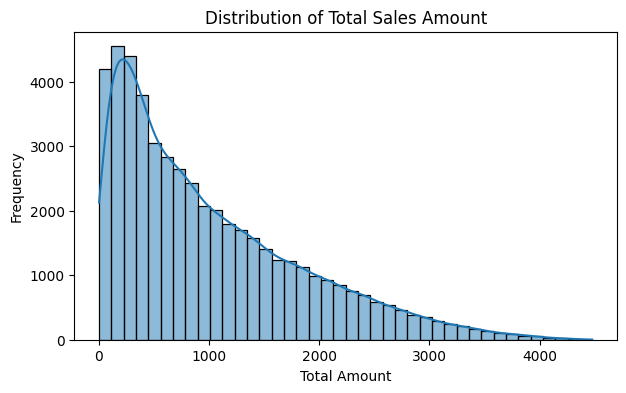

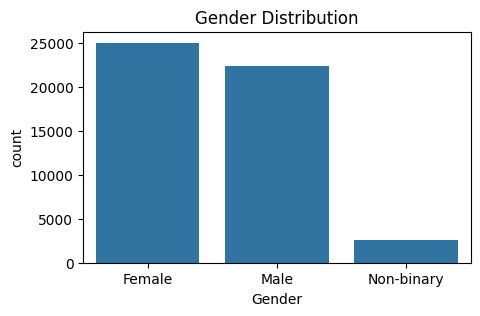

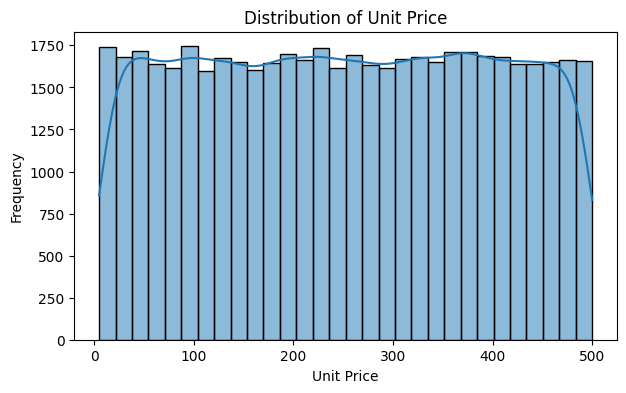

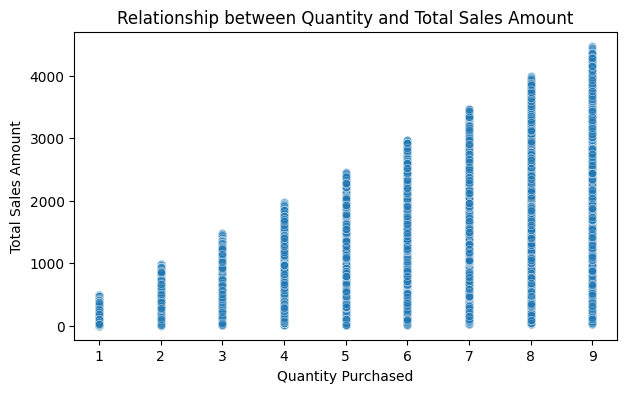

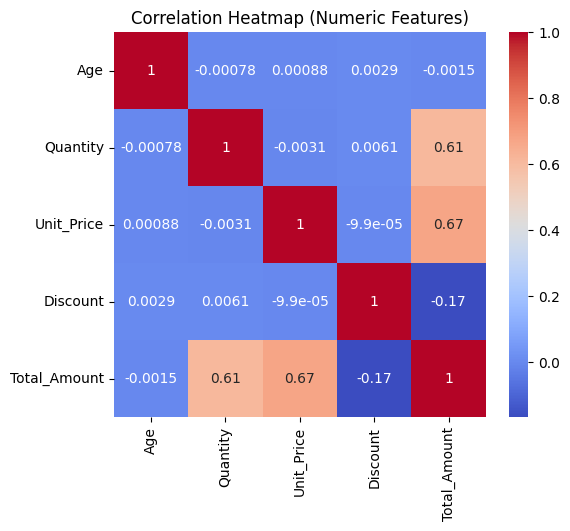

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Total Amount
plt.figure(figsize=(7,4))
sns.histplot(df["Total_Amount"], bins=40, kde=True)
plt.title("Distribution of Total Sales Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

# Gender Distribution
plt.figure(figsize=(5,3))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df["Unit_Price"], bins=30, kde=True)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(7,4))
sns.scatterplot(x="Quantity", y="Total_Amount", data=df, alpha=0.5)
plt.title("Relationship between Quantity and Total Sales Amount")
plt.xlabel("Quantity Purchased")
plt.ylabel("Total Sales Amount")
plt.show()

corr = df[["Age","Quantity","Unit_Price","Discount","Total_Amount"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

## Split & Preprocess (ColumnTransformer)

In [18]:

target_col = "Total_Amount"

feature_cols = [
    "Gender","Age","Category","Quantity","Unit_Price","Discount",
    "Store_Region","Online_Or_Offline","Payment_Method",
    "Year","Month","DayOfWeek","IsWeekend","Season"
]

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ["Age","Quantity","Unit_Price","Discount","Year","Month","DayOfWeek","IsWeekend"]
categorical_features = ["Gender","Category","Store_Region","Online_Or_Offline","Payment_Method","Season"]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## Train & Evaluate Models

In [19]:

models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)
}

metrics = []
preds_store = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = float(np.sqrt(mse))

    metrics.append({"Model": name, "R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse})
    preds_store[name] = (pipe, y_pred)

perf_df = pd.DataFrame(metrics).sort_values("RMSE")
perf_df


,Model,R2,MAE,MSE,RMSE
1,RandomForestRegressor,0.999864,6.083556,96.714040,9.834330
2,GradientBoostingRegressor,0.998397,25.969342,1141.953583,33.792804
0,LinearRegression,0.859550,232.258364,100048.031090,316.303701


## Visuals: Actual vs Predicted, Residuals, Feature Importances, Heatmap

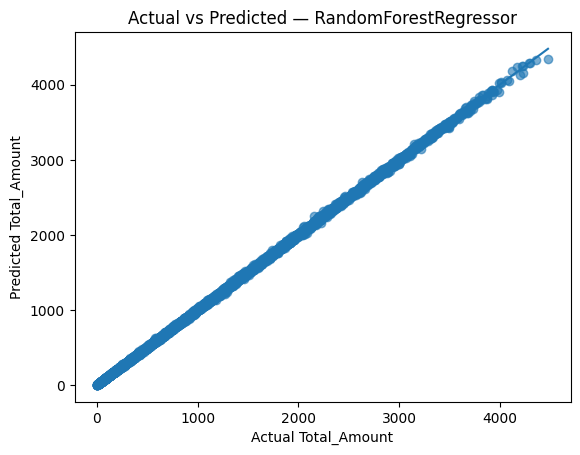

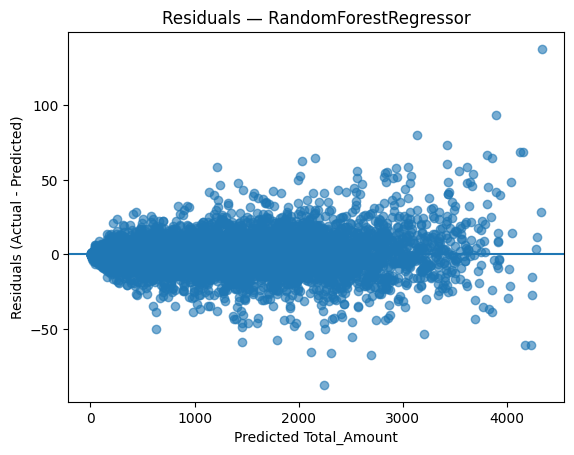

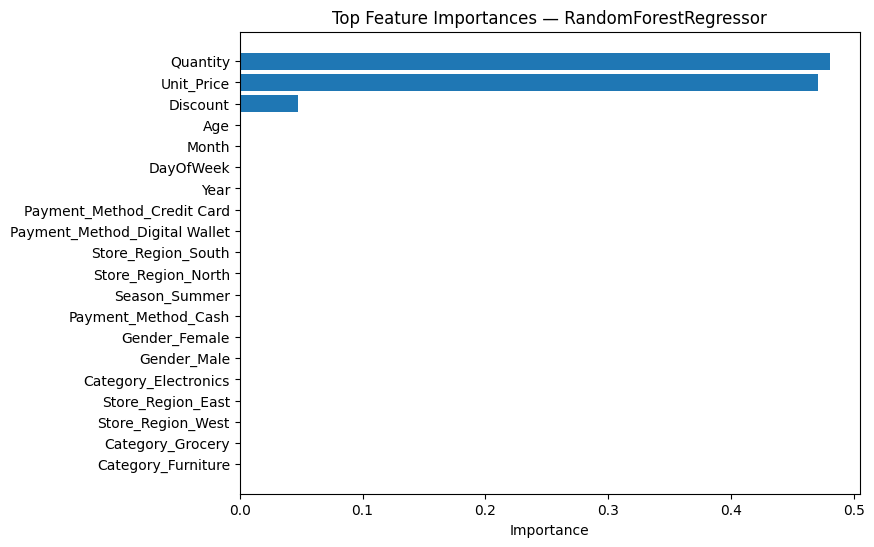

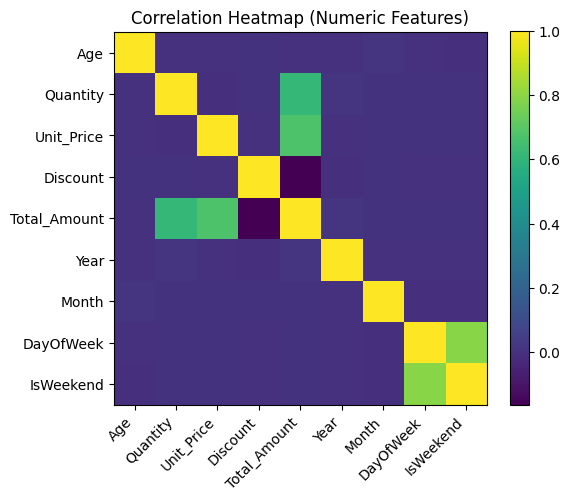

In [20]:

best_model_name = perf_df.iloc[0]["Model"]
best_pipe, best_pred = preds_store[best_model_name]

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, best_pred, alpha=0.6)
plt.xlabel("Actual Total_Amount")
plt.ylabel("Predicted Total_Amount")
plt.title(f"Actual vs Predicted — {best_model_name}")
mn = float(min(y_test.min(), best_pred.min()))
mx = float(max(y_test.max(), best_pred.max()))
plt.plot([mn, mx], [mn, mx])
plt.show()

# Residuals
residuals = y_test - best_pred
plt.figure()
plt.scatter(best_pred, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted Total_Amount")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title(f"Residuals — {best_model_name}")
plt.show()

# Feature Importances (if tree-based)
try:
    ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
    num_names = numeric_features
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    feat_names = num_names + cat_names

    model = best_pipe.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        order = np.argsort(importances)[::-1]
        top_k = min(20, len(order))
        plt.figure(figsize=(8, max(4, 0.3*top_k)))
        plt.barh([feat_names[i] for i in order[:top_k]][::-1], importances[order[:top_k]][::-1])
        plt.xlabel("Importance")
        plt.title(f"Top Feature Importances — {best_model_name}")
        plt.show()
    else:
        print("Feature importances not available for:", best_model_name)
except Exception as e:
    print("Feature importance step skipped ->", e)

# Correlation heatmap (numeric only)
num_df = df[["Age","Quantity","Unit_Price","Discount","Total_Amount","Year","Month","DayOfWeek","IsWeekend"]].copy()
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Numeric Features)")
plt.colorbar()
plt.tight_layout()
plt.show()


## Save Performance Summary & Short Report

In [21]:

OUTPUT_DIR = "project2_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save performance table
perf_path = os.path.join(OUTPUT_DIR, "performance_summary.csv")
perf_df.to_csv(perf_path, index=False)
print("Saved performance summary to:", perf_path)

# Short markdown report
report_lines = []
report_lines.append("# CS667 Project 2 — Regression Modeling Report\n")
report_lines.append(f"**Date:** {datetime.now().strftime('%Y-%m-%d')}\n")
report_lines.append("## Overview\nWe predict **Total_Amount** per transaction using demographics, product/category, price/discount, channel, payment, region, and calendar features.\n")
report_lines.append("## Data Preparation\n- Parsed `Date`; engineered `Year`, `Month`, `DayOfWeek`, `IsWeekend`, and `Season`.\n- One-hot encoded categorical features (ignore unknowns) and standardized numeric features via `ColumnTransformer`.\n")
report_lines.append("## Models & Metrics\n")
report_lines.append(perf_df.to_markdown(index=False))
report_lines.append("\n")
report_lines.append(f"**Best model by RMSE:** **{perf_df.iloc[0]['Model']}**\n")
report_lines.append("## Visuals\n- Actual vs Predicted\n- Residuals\n- Feature Importances (tree-based)\n- Correlation Heatmap\n")
report_lines.append("## Insights\n- `Quantity` & `Unit_Price` typically drive `Total_Amount`; `Discount` adjusts basket size.\n- Temporal and channel features add lift (seasonality/weekend; online/offline effects).\n- Category and region capture product mix and regional preferences.\n")
report_lines.append("## Next Steps\n- Hyperparameter tuning for the best ensemble model.\n- Interaction features (e.g., `Quantity * Unit_Price`).\n- SHAP values for explainability.\n")

report_md = os.path.join(OUTPUT_DIR, "Project_2_Report.md")
with open(report_md, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Saved report to:", report_md)


Saved performance summary to: project2_outputs/performance_summary.csv
Saved report to: project2_outputs/Project_2_Report.md
